In [2]:
import pandas as pd
from matplotlib import pyplot as plt

In [3]:
#loading a dataset with pandas
data = pd.read_csv("Symptom2Disease.csv")

In [4]:
data

,Unnamed: 0,label,text
0,0,Psoriasis,I have been experiencing a skin rash on my arm...
1,1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,2,Psoriasis,I have been experiencing joint pain in my fing...
3,3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,4,Psoriasis,"My nails have small dents or pits in them, and..."
...,...,...,...
1195,295,diabetes,I'm shaking and trembling all over. I've lost ...
1196,296,diabetes,"Particularly in the crevices of my skin, I hav..."
1197,297,diabetes,I regularly experience these intense urges and...
1198,298,diabetes,"I have trouble breathing, especially outside. ..."


In [5]:
# droping column unnamed as it has no use
data.columns

Index(['Unnamed: 0', 'label', 'text'], dtype='object')

In [6]:
data = data.drop(columns = ['Unnamed: 0'])

In [7]:
data

,label,text
0,Psoriasis,I have been experiencing a skin rash on my arm...
1,Psoriasis,"My skin has been peeling, especially on my kne..."
2,Psoriasis,I have been experiencing joint pain in my fing...
3,Psoriasis,"There is a silver like dusting on my skin, esp..."
4,Psoriasis,"My nails have small dents or pits in them, and..."
...,...,...
1195,diabetes,I'm shaking and trembling all over. I've lost ...
1196,diabetes,"Particularly in the crevices of my skin, I hav..."
1197,diabetes,I regularly experience these intense urges and...
1198,diabetes,"I have trouble breathing, especially outside. ..."


In [8]:
#lowercasing our dataset
data['label'] =data['label'].str.lower()
data['text'] =data['text'].str.lower()

In [9]:
data

,label,text
0,psoriasis,i have been experiencing a skin rash on my arm...
1,psoriasis,"my skin has been peeling, especially on my kne..."
2,psoriasis,i have been experiencing joint pain in my fing...
3,psoriasis,"there is a silver like dusting on my skin, esp..."
4,psoriasis,"my nails have small dents or pits in them, and..."
...,...,...
1195,diabetes,i'm shaking and trembling all over. i've lost ...
1196,diabetes,"particularly in the crevices of my skin, i hav..."
1197,diabetes,i regularly experience these intense urges and...
1198,diabetes,"i have trouble breathing, especially outside. ..."


In [10]:
#punctuations
import string
exclude = string.punctuation

def remove_punct(text):
    return text.translate(str.maketrans("","",exclude))
    

In [11]:
data

,label,text
0,psoriasis,i have been experiencing a skin rash on my arm...
1,psoriasis,"my skin has been peeling, especially on my kne..."
2,psoriasis,i have been experiencing joint pain in my fing...
3,psoriasis,"there is a silver like dusting on my skin, esp..."
4,psoriasis,"my nails have small dents or pits in them, and..."
...,...,...
1195,diabetes,i'm shaking and trembling all over. i've lost ...
1196,diabetes,"particularly in the crevices of my skin, i hav..."
1197,diabetes,i regularly experience these intense urges and...
1198,diabetes,"i have trouble breathing, especially outside. ..."


In [12]:
import string
exclude = string.punctuation

def remove_punc_string(text):
    return text.translate(str.maketrans('','',exclude))

# Just for testing
text = "KKKKK,.,.,,r,,tgd,.d,fa.D,"
print(remove_punc_string(text))

KKKKKrtgddfaD


In [13]:
data['text']=data['text'].apply(remove_punct)
data['label']=data['label'].apply(remove_punct)

In [14]:
 # stopwords haru hatauna aghi stopwords bata punctuations hatam
from nltk.corpus import stopwords
stop_word = stopwords.words("english")

clean_stopwords = [w.translate(str.maketrans('','',string.punctuation))for w in stop_word]


In [15]:
# aba Stopwords ko lagii
import nltk
def remove_stopwords(text):
    new_text = []
    for word in text.split():
        if word not in clean_stopwords:
            new_text.append(word)

    x = new_text[:]
    new_text.clear()
    return " ".join(x)

In [16]:
data['text'] = data['text'].apply(remove_stopwords)

In [17]:
data

,label,text
0,psoriasis,experiencing skin rash arms legs torso past we...
1,psoriasis,skin peeling especially knees elbows scalp pee...
2,psoriasis,experiencing joint pain fingers wrists knees p...
3,psoriasis,silver like dusting skin especially lower back...
4,psoriasis,nails small dents pits often feel inflammatory...
...,...,...
1195,diabetes,shaking trembling lost sense taste smell exhau...
1196,diabetes,particularly crevices skin skin rashes irritat...
1197,diabetes,regularly experience intense urges want urinat...
1198,diabetes,trouble breathing especially outside start fee...


In [18]:
data.sample(5)

,label,text
947,urinary tract infection,pee frequently odd smell either red black freq...
329,fungal infection,pretty uncomfortable itch body red bumpy areas...
695,hypertension,woke morning feeling fine day went started exp...
461,dimorphic hemorrhoids,lot trouble going bathroom lately really painf...
280,dengue,developed skin rash covers entire body rash re...


In [19]:
data

,label,text
0,psoriasis,experiencing skin rash arms legs torso past we...
1,psoriasis,skin peeling especially knees elbows scalp pee...
2,psoriasis,experiencing joint pain fingers wrists knees p...
3,psoriasis,silver like dusting skin especially lower back...
4,psoriasis,nails small dents pits often feel inflammatory...
...,...,...
1195,diabetes,shaking trembling lost sense taste smell exhau...
1196,diabetes,particularly crevices skin skin rashes irritat...
1197,diabetes,regularly experience intense urges want urinat...
1198,diabetes,trouble breathing especially outside start fee...


In [20]:
# Learning how to tokenize

# # time for tokenization;
# from nltk.tokenize import sent_tokenize , word_tokenize
# word_tokenize(X_train[0])
# sent = sent_tokenize(Y_train[0])
# sent_tokenize(Y_train[0])

# next step --using TF-IDF ---- term frequency * inverse document frequency


In [21]:
print(data['text'][9])

skin genitals red inflamed often itchy burning uncomfortable rashes different parts body


In [22]:
#Tokenization
from nltk.tokenize import sent_tokenize , word_tokenize
def tokenization(text):
    return word_tokenize(text)

In [23]:
data['text']= data['text'].apply(tokenization)

In [24]:
data

,label,text
0,psoriasis,"[experiencing, skin, rash, arms, legs, torso, ..."
1,psoriasis,"[skin, peeling, especially, knees, elbows, sca..."
2,psoriasis,"[experiencing, joint, pain, fingers, wrists, k..."
3,psoriasis,"[silver, like, dusting, skin, especially, lowe..."
4,psoriasis,"[nails, small, dents, pits, often, feel, infla..."
...,...,...
1195,diabetes,"[shaking, trembling, lost, sense, taste, smell..."
1196,diabetes,"[particularly, crevices, skin, skin, rashes, i..."
1197,diabetes,"[regularly, experience, intense, urges, want, ..."
1198,diabetes,"[trouble, breathing, especially, outside, star..."


In [25]:
# stemming---words lai root form ma lagne!!
from nltk import PorterStemmer
stemmer = PorterStemmer()
def Stemming(text):
    return " ".join(stemmer.stem(word) for word in text)

In [26]:
data['text']=data['text'].apply(Stemming)

In [27]:
#Difference between lemmatization and stemming
# The big difference between Lemmatization  and stemming is that Lemmatization  
# picks up a word that is in the english dictioanry but in case of stemming the word may or may not be in dictonary

In [28]:
# now for train-test split
from sklearn.model_selection import train_test_split
X = data['text']
y = data['label']

X_train, X_test, Y_train, Y_test = train_test_split( X, y, test_size= 0.2, random_state= 42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(960,)
(240,)


In [29]:
# Pipeline for TF-IDF vectorization and model

# First using sklearn for model training then only tensorflow. 
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier


model = Pipeline([("Vectorizer",TfidfVectorizer()),("Classifier",MLPClassifier(hidden_layer_sizes=(128,64),activation='relu',max_iter=500,random_state=42))])
print("Training model")
model.fit(X_train,Y_train)
print("Model Trained")

Training model
Model Trained


In [30]:
#Model evaluation
from sklearn.metrics import accuracy_score

#prediction from model
predictions = model.predict(X_test)

# Calculating accuracy
accuracy = accuracy_score(Y_test, predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

Model Accuracy: 96.67%



In [31]:
# classification report
from sklearn.metrics import classification_report
print(classification_report(y_pred =predictions,y_true= Y_test))

                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00        10
                        allergy       1.00      0.90      0.95        10
                      arthritis       1.00      1.00      1.00        10
               bronchial asthma       1.00      1.00      1.00        10
           cervical spondylosis       1.00      1.00      1.00        10
                    chicken pox       1.00      0.80      0.89        10
                    common cold       1.00      1.00      1.00        10
                         dengue       0.91      1.00      0.95        10
                       diabetes       1.00      0.90      0.95        10
          dimorphic hemorrhoids       1.00      1.00      1.00        10
                  drug reaction       0.83      1.00      0.91        10
               fungal infection       0.91      1.00      0.95        10
gastroesophageal reflux disease       0.83      1.

In [32]:
symtoms = [""]

print(model.predict(symtoms))

['diabetes']


In [33]:
data.sample(5)

,label,text
1076,drug reaction,chest pain extrem nausea present recent chest ...
158,chicken pox,worri rash skin spread rapidli caus lot discom...
1038,gastroesophageal reflux disease,feel like food acid back throat chest discomfo...
870,malaria,strong itchi chill nausea high temperatur plag...
822,jaundice,feel extrem scratchi sick worn addit lost weig...


In [34]:
#Now using tensorflow for model training

import tensorflow as tf
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout, Input

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# For Feature Engineering using TF_IDF
vectorizer = TfidfVectorizer()
X_train_tfidf = vectorizer.fit_transform(X_train).toarray() 
X_test_tfidf = vectorizer.transform(X_test).toarray()

encoder = LabelEncoder()
Y_train_encoded = encoder.fit_transform(Y_train)
Y_test_encoded = encoder.transform(Y_test)

model = Sequential([
    Input(shape=(X_train_tfidf.shape[1],)),
    Dense(128, activation = "relu", name ="layer_1"),
    Dropout(0.5),
    Dense(64, activation = "relu", name ="layer_2"),
    Dense(24, activation = "softmax", name = "output")
])

model.compile(optimizer ="adam",loss ="sparse_categorical_crossentropy",metrics=['accuracy'])

history = model.fit(X_train_tfidf, Y_train_encoded,epochs=20,validation_data=(X_test_tfidf, Y_test_encoded))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.1333 - loss: 3.1505 - val_accuracy: 0.4250 - val_loss: 3.1001
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4260 - loss: 3.0132 - val_accuracy: 0.6542 - val_loss: 2.8715
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6156 - loss: 2.6635 - val_accuracy: 0.7792 - val_loss: 2.3717
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7677 - loss: 2.0485 - val_accuracy: 0.8542 - val_loss: 1.6759
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8740 - loss: 1.3560 - val_accuracy: 0.9167 - val_loss: 1.0953
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9187 - loss: 0.8674 - val_accuracy: 0.9208 - val_loss: 0.7460
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9583 - loss: 0.5452 - val_accuracy: 0.9417 - val_loss: 0.5393
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9698 - loss: 0.3949 - val_accuracy: 0.9542 - v

In [35]:
def predict_disease(symptom_text):
    vec = vectorizer.transform([symptom_text]).toarray()
    pred = model.predict(vec)
    disease = encoder.inverse_transform([pred.argmax()])
    return disease[0]

# Example
predict_disease("I have a skin rash and joint pain")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


'psoriasis'

In [36]:
from sklearn.metrics import classification_report

Y_pred_encoded = model.predict(X_test_tfidf).argmax(axis=1)
Y_pred_labels  = encoder.inverse_transform(Y_pred_encoded)
Y_test_labels  = encoder.inverse_transform(Y_test_encoded)

print(classification_report(Y_test_labels, Y_pred_labels))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
                                 precision    recall  f1-score   support

                           acne       1.00      1.00      1.00        10
                        allergy       1.00      0.90      0.95        10
                      arthritis       1.00      1.00      1.00        10
               bronchial asthma       1.00      1.00      1.00        10
           cervical spondylosis       1.00      1.00      1.00        10
                    chicken pox       1.00      1.00      1.00        10
                    common cold       1.00      1.00      1.00        10
                         dengue       0.83      1.00      0.91        10
                       diabetes       1.00      0.80      0.89        10
          dimorphic hemorrhoids       1.00      1.00      1.00        10
                  drug reaction       0.91      1.00      0.95        10
               fungal infection       1.00      1.00      1.00        10
gastroesopha

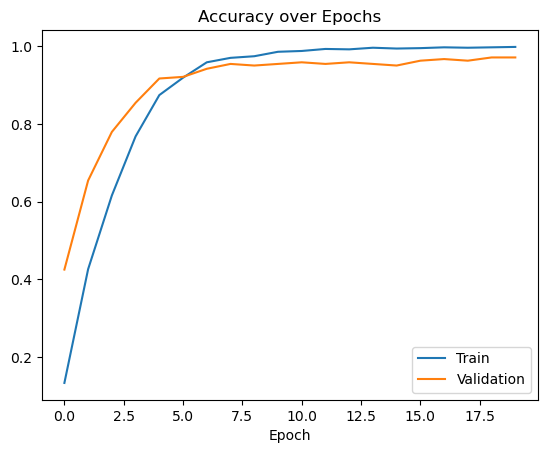

In [38]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.show()

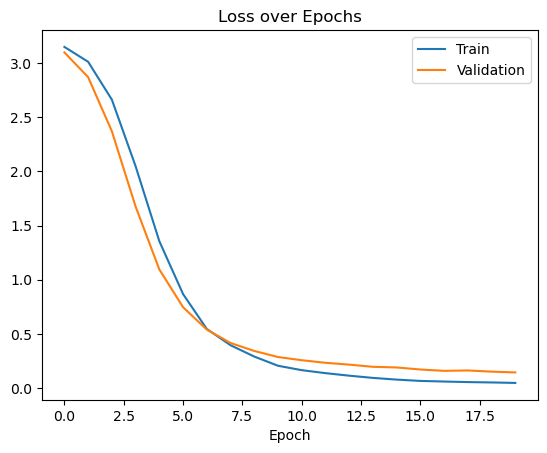

In [39]:
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.legend()
plt.show()